<a href="https://colab.research.google.com/github/polokocodes/Data-Science---ML-Projects/blob/main/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Prepare the data

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [40]:
#Create a Churn data(CC_data) variable using the data
CC_data = pd.read_csv('/content/customer_churn.csv')
CC_data.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1


In [42]:
#Check the data type
CC_data.dtypes


,0
Names,object
Age,float64
Total_Purchase,float64
Account_Manager,int64
Years,float64
Num_Sites,float64
Onboard_date,object
Location,object
Company,object
Churn,int64


In [43]:
#Data description
print("Data description: \n",CC_data.describe())
#Data shape
print("Data columns(10) and rows(250): \n",CC_data.shape)
#Name of features and targets
print("\n Columns: \n",CC_data.columns.tolist())
#Number of missing data
print("\n Missing data: \n", CC_data.isnull().sum())

Data description: 
               Age  Total_Purchase  ...   Num_Sites       Churn
count  900.000000      900.000000  ...  900.000000  900.000000
mean    41.816667    10062.824033  ...    8.587778    0.166667
std      6.127560     2408.644532  ...    1.764836    0.372885
min     22.000000      100.000000  ...    3.000000    0.000000
25%     38.000000     8497.122500  ...    7.000000    0.000000
50%     42.000000    10045.870000  ...    8.000000    0.000000
75%     46.000000    11760.105000  ...   10.000000    0.000000
max     65.000000    18026.010000  ...   14.000000    1.000000

[8 rows x 6 columns]
Data columns(10) and rows(250): 
 (900, 10)

 Columns: 
 ['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn']

 Missing data: 
 Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Chu

In [44]:
CC_data['Age'].value_counts()

,count
Age,
41.0,69
43.0,59
40.0,58
45.0,56
44.0,53
38.0,51
42.0,49
37.0,48
46.0,48


In [45]:
# Define clear, simple age bins for our categories
age_bins = [0, 15, 55, 100] # 0-14 (Child), 15-54 (Adult), 55-100 (Senior)
age_labels = ['Child (0-14)', 'Adult (15-54)', 'Senior (55+)' ]
CC_data['Age_Category'] = pd.cut(CC_data['Age'], bins=age_bins, labels=age_labels, right=False)


In [46]:
CC_data.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Age_Category
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Adult (15-54)
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Adult (15-54)
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Adult (15-54)
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,Adult (15-54)
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Adult (15-54)


# Step 2:EDA

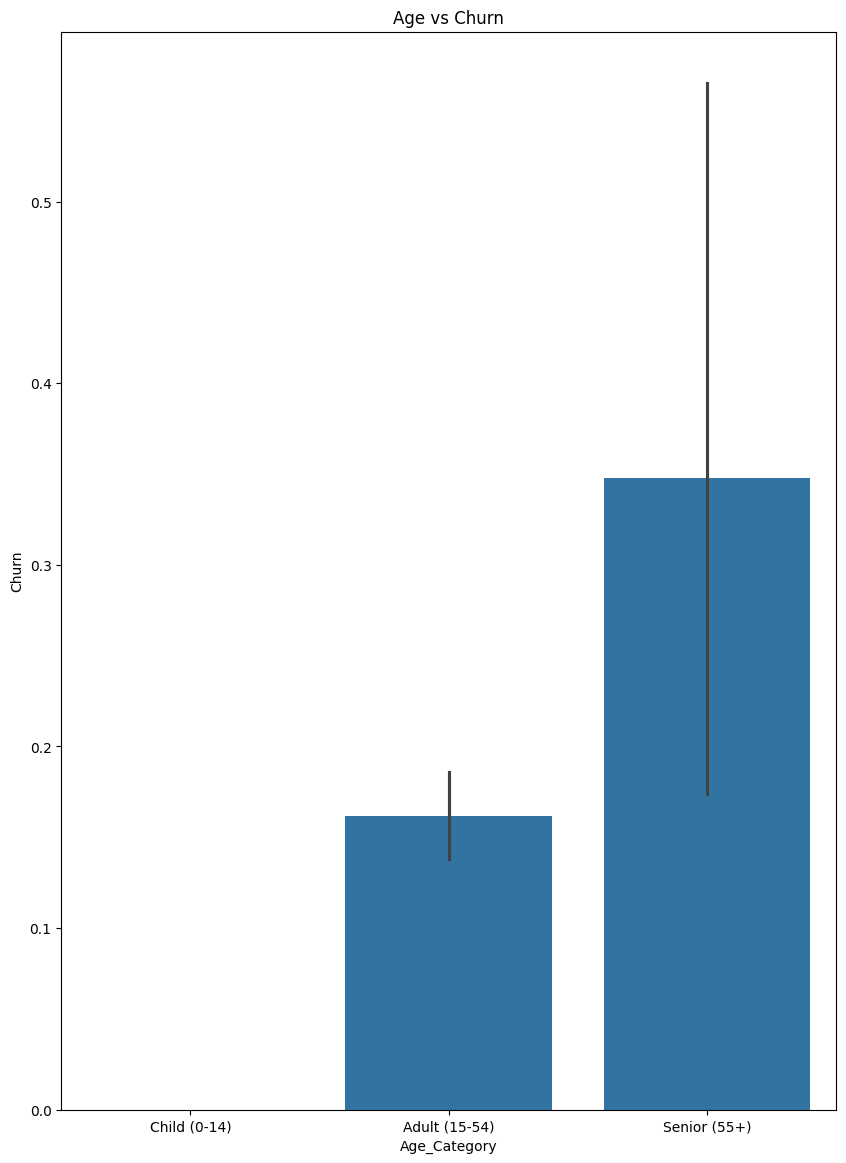

In [47]:
#Find how age affects customer churn
plt.figure(figsize=(10,14))
sns.barplot(x='Age_Category', y='Churn', data=CC_data)
plt.title('Age vs Churn')
plt.show()



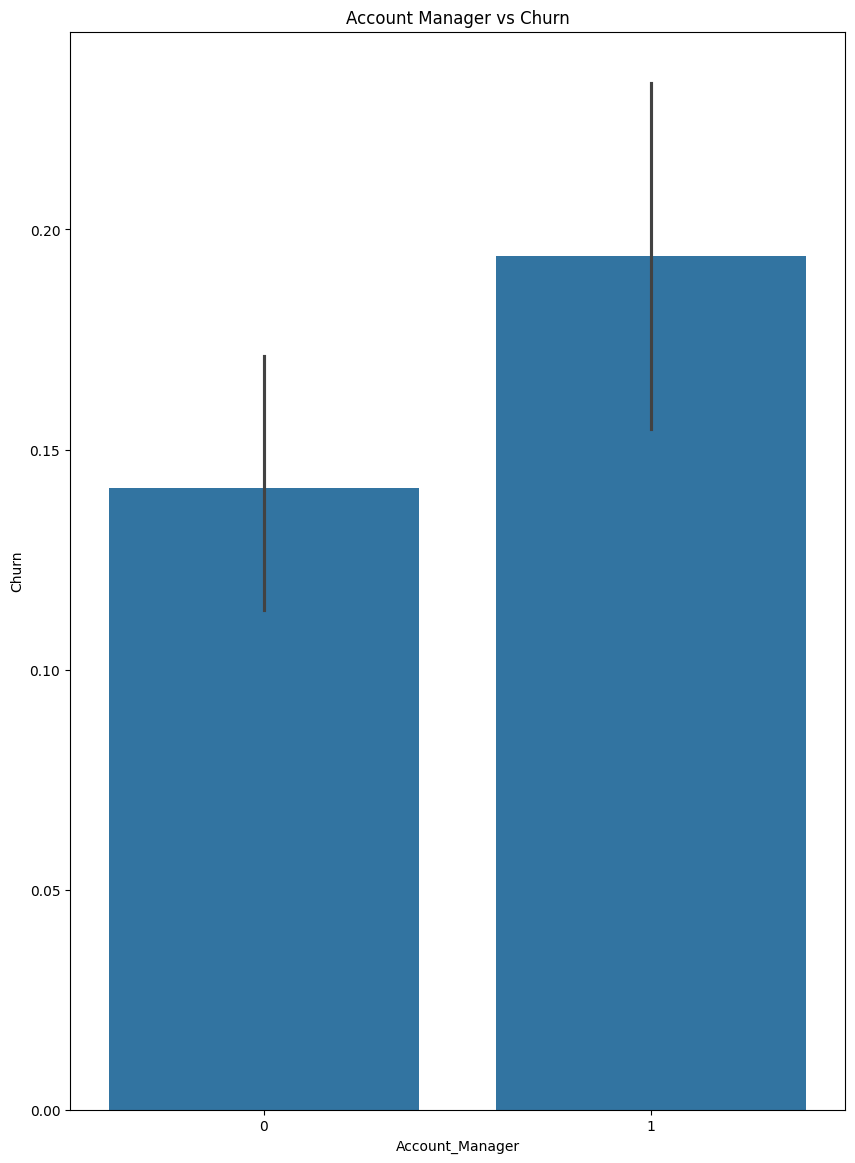

In [48]:
#How the having an account manager affect churn
plt.figure(figsize=(10,14))
sns.barplot(x='Account_Manager', y='Churn', data=CC_data)
plt.title('Account Manager vs Churn')
plt.show()

In [49]:
CC_data.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Age_Category
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Adult (15-54)
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Adult (15-54)


# Step3: Train The Models

In [51]:
#Define the target variable
y = CC_data['Churn']

In [57]:
#Define the features to drop
#CC_data.columns.tolist()
#CC_data.dtypes
features_to_drop = ['Names','Onboard_date','Location','Company','Churn','Age_Category']
X = CC_data.drop(features_to_drop, axis=1, errors='ignore')

In [61]:
train_X,test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

In [65]:
#Model Selection and training
model = LogisticRegression(random_state=42, max_iter=2000)
model.fit(train_X, train_y)

#Model prediction
model_prediction = model.predict(test_X)

#Model Evaluation
log_reg_accuracy = accuracy_score(test_y,model_prediction )

print(f"1. Logistic Regression Validation Accuracy (Baseline): {log_reg_accuracy *100}%")




1. Logistic Regression Validation Accuracy (Baseline): 90.0%


In [73]:
classification_report(test_y, model_prediction)

'              precision    recall  f1-score   support\n\n           0       0.92      0.96      0.94       148\n           1       0.77      0.62      0.69        32\n\n    accuracy                           0.90       180\n   macro avg       0.85      0.79      0.82       180\nweighted avg       0.89      0.90      0.90       180\n'

Text(45.722222222222214, 0.5, 'Actual')

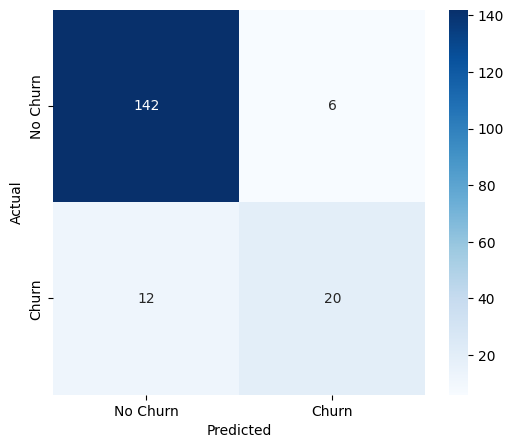

In [72]:
# We'll re-calculate the CM using the predictions from the chosen model on Test_X
cm = confusion_matrix(test_y, model.predict(test_X))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')


In [69]:
#Test on new data
CC_data_new = pd.read_csv('/content/new_customers_1.csv')
CC_data_new.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson


In [70]:
train_X_new,test_X_new, train_y_new, test_y_new = train_test_split(X, y, test_size=0.2, random_state=42)
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_X_new = scaler.fit_transform(train_X_new)
test_X_new = scaler.transform(test_X_new)

In [71]:
model.fit(train_X_new, train_y_new)
model_prediction_new = model.predict(test_X_new)
log_reg_accuracy_new = accuracy_score(test_y_new,model_prediction_new )
print(f"2. Logistic Regression Validation Accuracy (Baseline): {log_reg_accuracy_new *100}%")

2. Logistic Regression Validation Accuracy (Baseline): 90.0%
